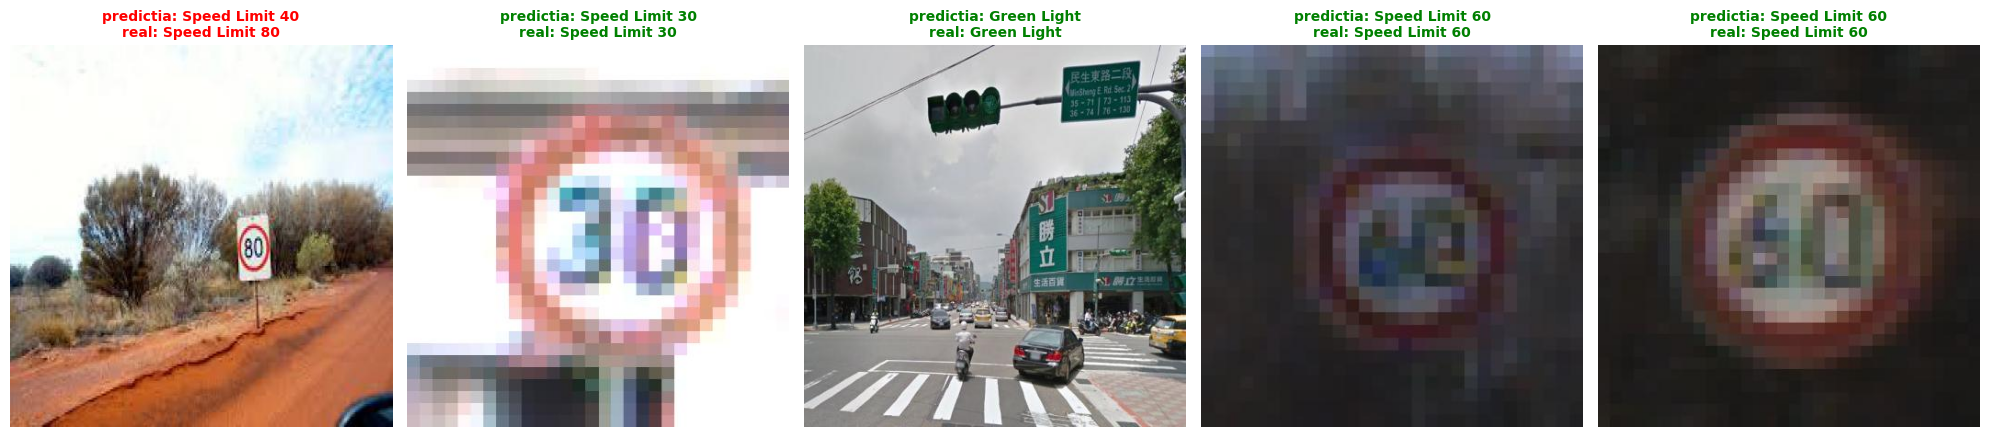

In [19]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import glob
import random
import yaml

#definirea clasei
class CustomTrafficNet(nn.Module):
    def __init__(self, num_classes=15):
        super(CustomTrafficNet, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(32,64,3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(64*8*8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x=self.conv_layers(x)
        x=x.view(x.size(0), -1)
        x=self.fc_layers(x)
        return x

#incarcarea datelor
data_path = '.'  
with open(os.path.join(DATA_PATH, 'data.yaml'), 'r') as f:
    data_yaml = yaml.safe_load(f)
classes = data_yaml['names']
num_classes = len(classes)

#incarcarea modelului
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomTrafficNet(num_classes=NUM_CLASSES).to(device)


model_path = 'traffic_sign_model_local3.pth' 
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()


transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])


def visualize_results_with_labels(model, dataset_path, split='test', num_images=5):
    images_path = os.path.join(dataset_path, split, 'images')
    labels_path = os.path.join(dataset_path, split, 'labels')
    all_images = glob.glob(os.path.join(images_path, "*.*"))
    
    if not all_images:
        print(f"Nu exista imagini in {images_path}!")
        return

    random_samples = random.sample(all_images, min(num_images, len(all_images)))
    plt.figure(figsize=(20, 7))
    
    with torch.no_grad():
        for i, img_path in enumerate(random_samples):
            filename = os.path.basename(img_path)
            label_filename = os.path.splitext(filename)[0] + ".txt"
            label_file_path = os.path.join(labels_path, label_filename)
            
            real_class_idx = -1
            real_class_name = "lipsa label"
            if os.path.exists(label_file_path):
                with open(label_file_path, 'r') as f:
                    content = f.readline().split()
                    if content:
                        real_class_idx = int(content[0])
                        real_class_name = classes[real_class_idx]

            #predictia
            raw_image = Image.open(img_path).convert("RGB")
            input_tensor = transform(raw_image).unsqueeze(0).to(device)
            outputs = model(input_tensor)
            _, predicted = torch.max(outputs, 1)
            pred_idx = predicted.item()
            pred_name = classes[pred_idx]
            
            # vizualizarea
            title_color = "green" if pred_idx == real_class_idx else "red"
            plt.subplot(1,num_images,i + 1)
            plt.imshow(raw_image)
            plt.title(f"predictia: {pred_name}\nreal: {real_class_name}", 
                      color=title_color, fontsize=10, fontweight='bold')
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()


visualize_results_with_labels(model, DATA_PATH, split='test', num_images=5)